In [1]:
%load_ext autoreload
%autoreload 2

# WebDataset + Emu3 Vision Tokenization Tutorial

This notebook demonstrates how to:
1. Load image data from WebDataset tar files
2. Tokenize images using the Emu3 vision tokenizer
3. Process data efficiently in batches
4. Save tokenized data in Megatron IndexedDataset format

## Overview

WebDataset is designed for handling large-scale datasets that don't fit in memory. It:
- Stores data in tar files for efficient sequential reading
- Supports streaming and parallel processing
- Integrates seamlessly with PyTorch DataLoader

The Emu3 vision tokenizer converts images into discrete tokens for use in vision-language models.

## 1. Setup and Imports

In [ ]:
import os
import sys
import json
import glob
import time
from pathlib import Path
from typing import List, Dict, Optional
import logging

import torch
import numpy as np
import webdataset as wds
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

# Add project path
sys.path.append('/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier')

# Import custom modules
from vision_tokenization.utils.indexed_dataset_megatron import VisionTokenIndexedDatasetBuilder
from Tokenizer.Emu3VisionTokenizer import Emu3VisionTokenizer

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print("Setup complete!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

## 2. Initialize Emu3 Vision Tokenizer

The Emu3 tokenizer converts images into discrete tokens using a learned codebook.
Key features:
- Vocabulary size: 131,072 tokens (2^17)
- Support Arbitrary Input shape

In [3]:
# Initialize tokenizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Initializing Emu3VisionTokenizer on {device}...")

tokenizer = Emu3VisionTokenizer(device=device)

# Get tokenizer properties
print(f"\nTokenizer properties:")
print(f"  Device: {device}")
print(f"  Vocabulary size: {2**17:,} tokens")

Initializing Emu3VisionTokenizer on cuda...
Loading Emu3VisionTokenizer from BAAI/Emu3-VisionTokenizer...
✓ Emu3VisionTokenizer loaded successfully
Emu3VisionTokenizer loaded:
  Total parameters: 270.74M (270,740,287)
  Trainable parameters: 270.74M (270,740,287)

Tokenizer properties:
  Device: cuda
  Vocabulary size: 131,072 tokens


## 3. Available Datasets

We have several datasets available at `/capstor/store/cscs/swissai/infra01/vision-datasets/`:

1. **LAION-400M**: Pre-sharded WebDataset tar files
2. **LLaVA-Pretrain**: Raw JPG images in subdirectories  
3. **CC3M, CC12M, COYO700M**: Various formats

Let's explore these datasets and demonstrate both scenarios: using existing tar files and creating tar files from raw images.

In [4]:
# Dataset paths
DATASET_ROOT = Path("/capstor/store/cscs/swissai/infra01/vision-datasets")

# Available datasets
datasets = {
    "laion400m": DATASET_ROOT / "laion400m/laion400m-data",  # Has tar files
    "llava_pretrain": DATASET_ROOT / "llava_pretrain/LLaVA-Pretrain",  # Has JPG files
    "cc3m": DATASET_ROOT / "cc3m/cc3m",
    "cc12m": DATASET_ROOT / "cc12m",
    "coyo700m": DATASET_ROOT / "coyo700m"
}

print("Available datasets:")
for name, path in datasets.items():
    if path.exists():
        print(f"  ✓ {name}: {path}")
    else:
        print(f"  ✗ {name}: {path} (not found)")

Available datasets:
  ✓ laion400m: /capstor/store/cscs/swissai/infra01/vision-datasets/laion400m/laion400m-data
  ✓ llava_pretrain: /capstor/store/cscs/swissai/infra01/vision-datasets/llava_pretrain/LLaVA-Pretrain
  ✓ cc3m: /capstor/store/cscs/swissai/infra01/vision-datasets/cc3m/cc3m
  ✓ cc12m: /capstor/store/cscs/swissai/infra01/vision-datasets/cc12m
  ✓ coyo700m: /capstor/store/cscs/swissai/infra01/vision-datasets/coyo700m


## 3a. Option 1: Use Existing WebDataset Tar Files (LAION-400M)

LAION-400M already comes as WebDataset tar files, so we can directly use them:

In [5]:
# Check LAION-400M tar files
laion_tar_files = sorted(glob.glob(str(datasets["laion400m"] / "*.tar")))
print(f"Found {len(laion_tar_files)} tar files in LAION-400M")

if laion_tar_files:
    # Show first few tar files
    print("\nFirst 5 tar files:")
    for tar_file in laion_tar_files[:5]:
        size_mb = Path(tar_file).stat().st_size / (1024 * 1024)
        print(f"  {Path(tar_file).name}: {size_mb:.2f} MB")
    
    # For demo, we'll use just the first few tar files
    demo_laion_tars = laion_tar_files[:3]
    print(f"\nUsing {len(demo_laion_tars)} tar files for demonstration")
    
    # Create pattern for WebDataset
    # For specific files, we can list them directly
    laion_tar_pattern = "{" + ",".join(demo_laion_tars) + "}"
    print(f"Pattern: {laion_tar_pattern[:100]}...")

Found 458 tar files in LAION-400M

First 5 tar files:
  00000.tar: 0.01 MB
  00001.tar: 0.01 MB
  00002.tar: 0.01 MB
  00003.tar: 0.01 MB
  00004.tar: 0.01 MB

Using 3 tar files for demonstration
Pattern: {/capstor/store/cscs/swissai/infra01/vision-datasets/laion400m/laion400m-data/00000.tar,/capstor/sto...


## 3b. Option 2: Create WebDataset from Raw Images (LLaVA-Pretrain)

LLaVA-Pretrain has raw JPG images that we can convert to WebDataset format:

In [6]:
def create_webdataset_from_images(image_dir, output_dir, num_shards=5, max_images=1000):
    """
    Create WebDataset tar files from a directory of images.
    
    Args:
        image_dir: Directory containing images (can have subdirectories)
        output_dir: Where to save the tar files
        num_shards: Number of tar files to create
        max_images: Maximum number of images to process (None for all)
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Collect image paths - handle nested structure
    print(f"Scanning {image_dir} for images...")
    image_paths = []
    
    # For LLaVA structure: /path/00000/*.jpg, /path/00001/*.jpg, etc.
    for pattern in ["*.jpg", "*.jpeg", "*.png", "*.webp"]:
        # Check root directory
        found = list(image_dir.glob(pattern))
        if found:
            print(f"  Found {len(found)} {pattern} files in root")
            image_paths.extend(found)
        
        # Check one level deep (like LLaVA: 00000/*.jpg)
        found = list(image_dir.glob(f"*/{pattern}"))
        if found:
            print(f"  Found {len(found)} {pattern} files in subdirectories")
            image_paths.extend(found)
        
        # Check two levels deep if needed
        found = list(image_dir.glob(f"*/*/{pattern}"))
        if found:
            print(f"  Found {len(found)} {pattern} files in nested subdirectories")
            image_paths.extend(found)
    
    # Remove duplicates and sort
    image_paths = sorted(list(set(image_paths)))
    print(f"Total unique images found: {len(image_paths)}")
    
    if not image_paths:
        print("WARNING: No images found!")
        return []
    
    # Limit number of images for demo
    if max_images and len(image_paths) > max_images:
        image_paths = image_paths[:max_images]
        print(f"Limiting to {max_images} images for demo")
    
    # Calculate sharding
    images_per_shard = len(image_paths) // num_shards + 1
    
    # Create shards
    created_shards = []
    for shard_idx in range(num_shards):
        start_idx = shard_idx * images_per_shard
        end_idx = min((shard_idx + 1) * images_per_shard, len(image_paths))
        
        if start_idx >= len(image_paths):
            break
        
        shard_path = output_dir / f"shard-{shard_idx:06d}.tar"
        print(f"Creating {shard_path.name} ({end_idx - start_idx} images)...")
        
        with wds.TarWriter(str(shard_path)) as sink:
            for img_idx in range(start_idx, end_idx):
                img_path = image_paths[img_idx]
                
                # Create unique key
                key = f"{shard_idx:06d}_{img_idx:08d}"
                
                try:
                    with open(img_path, 'rb') as f:
                        img_data = f.read()
                    
                    # Get extension
                    ext = img_path.suffix.lower().lstrip('.')
                    if ext == 'jpeg':
                        ext = 'jpg'
                    
                    # Create sample
                    sample = {
                        "__key__": key,
                        ext: img_data,
                        "json": json.dumps({
                            "original_path": str(img_path),
                            "relative_path": str(img_path.relative_to(image_dir)),
                            "index": img_idx,
                            "shard": shard_idx
                        }).encode()
                    }
                    
                    sink.write(sample)
                except Exception as e:
                    print(f"  Warning: Failed to process {img_path}: {e}")
        
        created_shards.append(shard_path)
        print(f"  Created {shard_path.name} successfully")
    
    return created_shards

# Create WebDataset shards from LLaVA images
output_dir = Path("llava_webdataset_demo")
created_shards = create_webdataset_from_images(
    datasets["llava_pretrain"],
    output_dir,
    num_shards=3,
    max_images=300  # Just use 300 images for demo
)

if created_shards:
    print(f"\nSuccessfully created {len(created_shards)} shards in {output_dir}")
    llava_tar_pattern = str(output_dir / "shard-{000000..000002}.tar")
else:
    print("\nFailed to create shards - no images found")
    llava_tar_pattern = None

Scanning /capstor/store/cscs/swissai/infra01/vision-datasets/llava_pretrain/LLaVA-Pretrain for images...
  Found 558128 *.jpg files in subdirectories
  Found 4 *.png files in subdirectories
Total unique images found: 558132
Limiting to 300 images for demo
Creating shard-000000.tar (101 images)...
  Created shard-000000.tar successfully
Creating shard-000001.tar (101 images)...
  Created shard-000001.tar successfully
Creating shard-000002.tar (98 images)...
  Created shard-000002.tar successfully

Successfully created 3 shards in llava_webdataset_demo


## Understanding WebDataset Format

WebDataset stores data in tar files with a specific structure:
- **`__key__`**: Required unique identifier for each sample (becomes the base filename)
- **Data files**: Each field in the sample dict becomes a file with the key as basename
- **Grouping**: Files with the same basename are automatically grouped as one sample

Example: A sample with `__key__: "001"` and fields `jpg`, `json` creates:
- `001.jpg` (image data)
- `001.json` (metadata - optional)

When loading, WebDataset groups these files back together as one sample.

Using LLaVA tar files
Loading WebDataset from: llava_webdataset_demo/shard-{000000..000002}.tar...

Loading sample images...
Loaded image 0: size=(681, 336)
Loaded image 1: size=(336, 336)
Loaded image 2: size=(337, 336)
Loaded image 3: size=(448, 336)
Loaded image 4: size=(336, 336)
Loaded image 5: size=(448, 336)


/usr/local/lib/python3.10/dist-packages/webdataset/compat.py:136: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


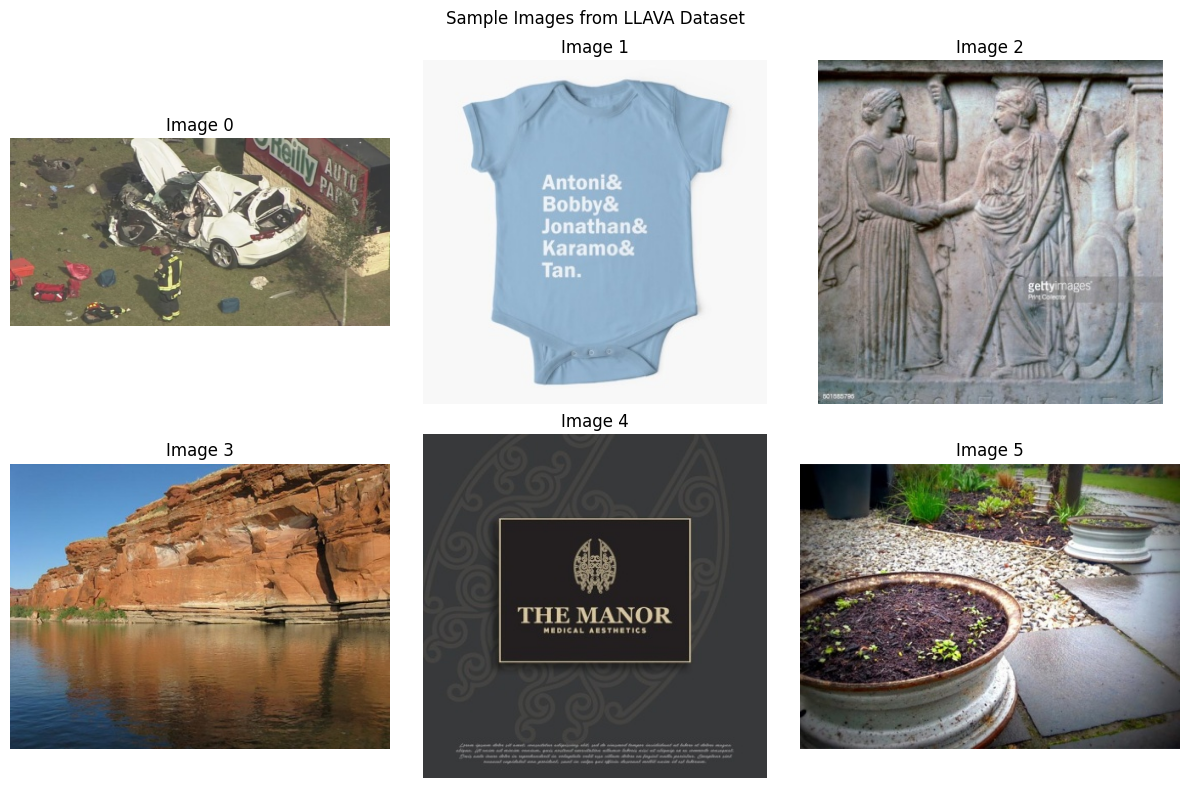


Successfully loaded 6 images from WebDataset!


In [7]:
# Choose dataset to use
USE_DATASET = "llava"  # Change to "laion" to use LAION-400M instead

if USE_DATASET == "laion" and laion_tar_files:
    print("Using LAION-400M tar files")
    tar_pattern = laion_tar_pattern
elif USE_DATASET == "llava":
    print("Using LLaVA tar files")
    tar_pattern = llava_tar_pattern
else:
    raise ValueError(f"Dataset '{USE_DATASET}' not available")

print(f"Loading WebDataset from: {tar_pattern[:100]}...")

# Create dataset pipeline
dataset = (
    wds.WebDataset(tar_pattern)
    .decode("pil")  # Decode images to PIL format
    .to_tuple("jpg;png;jpeg;webp", "json")  # Extract image and metadata (handles multiple formats)
)

# Load and display sample images
print("\nLoading sample images...")
sample_images = []
sample_metadata = []

for i, (img, meta_json) in enumerate(dataset):
    if i >= 6:  # Load 6 images for display
        break
    sample_images.append(img)
    try:
        meta = json.loads(meta_json) if isinstance(meta_json, (str, bytes)) else {}
        sample_metadata.append(meta)
    except:
        sample_metadata.append({})
    print(f"Loaded image {i}: size={img.size}")

# Display the images in a grid
if sample_images:
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    for idx, (img, ax) in enumerate(zip(sample_images, axes)):
        ax.imshow(img)
        ax.set_title(f"Image {idx}")
        ax.axis('off')
    
    plt.suptitle(f"Sample Images from {USE_DATASET.upper()} Dataset")
    plt.tight_layout()
    plt.show()
    
print(f"\nSuccessfully loaded {len(sample_images)} images from WebDataset!")

## 5. Test Single Image Tokenization

Let's test the tokenization process on a single image to understand the output:

In [8]:
def tokenize_image(tokenizer, pil_image):
    """
    Tokenize a single image using Emu3 tokenizer.
    
    Args:
        tokenizer: Emu3VisionTokenizer instance
        pil_image: PIL Image object
    
    Returns:
        tokens: 1D numpy array of token indices
        info: Dictionary with tokenization information
    """
    # Step 1: Preprocess image to tensor
    img_tensor = tokenizer.preprocess(pil_image)
    
    # Step 2: Encode to discrete tokens
    indices, additional_info = tokenizer.encode(img_tensor)
    
    # Step 3: Flatten spatial dimensions
    # Shape: [1, H, W] -> [H*W]
    flat_indices = indices.squeeze(0).flatten()
    
    # Convert to numpy for storage
    tokens = flat_indices.cpu().numpy()
    
    info = {
        "num_tokens": len(tokens),
        "spatial_shape": indices.shape[1:],  # (H, W)
        "min_token": int(tokens.min()),
        "max_token": int(tokens.max()),
        "unique_tokens": len(np.unique(tokens))
    }
    
    return tokens, info

# Test tokenization on a single image
print("Testing single image tokenization...")

# Get a sample image from our dataset
sample_img = None
for img, _ in dataset:
    sample_img = img
    break

if sample_img:
    with torch.no_grad():
        tokens, info = tokenize_image(tokenizer, sample_img)

    print(f"\nTokenization result:")
    for key, value in info.items():
        print(f"  {key}: {value}")

    print(f"\nFirst 20 tokens: {tokens[:20]}")
else:
    print("No sample image available for testing")

Testing single image tokenization...

Tokenization result:
  num_tokens: 4140
  spatial_shape: torch.Size([45, 92])
  min_token: 4
  max_token: 16372
  unique_tokens: 2594

First 20 tokens: [15976  1090  2312  5577  4707  6900   537  3861  9888  4335  5284  4171
  6535    33 12476 15953  7135  7255 15587  4332]


## 6. Full Tokenization of LLaVA WebDataset Shards

Now let's tokenize all images from the three LLaVA shards we created:

In [10]:
# Tokenize all images from the LLaVA WebDataset shards
print("Starting full tokenization of LLaVA WebDataset shards...")
print(f"Processing pattern: {llava_tar_pattern}")

# Create dataset pipeline (no batching due to variable sizes)
dataset = (
    wds.WebDataset(llava_tar_pattern)
    .decode("pil")
    .to_tuple("jpg;png;jpeg;webp", "json")
)

# Storage for all tokens and metadata
all_tokens = []
all_metadata = []
all_shapes = []

# Process all images
print("\nTokenizing images...")
start_time = time.time()

with torch.no_grad():
    for idx, (img, meta_json) in enumerate(tqdm(dataset, desc="Processing images")):
        try:
            # Parse metadata
            meta = json.loads(meta_json) if isinstance(meta_json, (str, bytes)) else {}
            
            # Tokenize image
            img_tensor = tokenizer.preprocess(img)
            indices, additional_info = tokenizer.encode(img_tensor)
            
            # Store shape before flattening
            token_shape = indices.shape[1:]  # (H, W) - this is a torch.Size object
            flat_indices = indices.squeeze(0).flatten()
            
            # Convert to numpy
            tokens_np = flat_indices.cpu().numpy()
            
            # Store results
            all_tokens.append(tokens_np)
            all_shapes.append(token_shape)
            all_metadata.append({
                **meta,
                "num_tokens": len(tokens_np),
                "spatial_shape": tuple(token_shape),  # torch.Size can be converted to tuple directly
                "image_size": img.size,
            })
            
            # Progress update
            if (idx + 1) % 50 == 0:
                elapsed = time.time() - start_time
                rate = (idx + 1) / elapsed
                print(f"  Processed {idx + 1} images ({rate:.1f} img/sec)")
                
        except Exception as e:
            print(f"  Error processing image {idx}: {e}")
            continue

# Calculate statistics
total_time = time.time() - start_time
total_images = len(all_tokens)
total_tokens = sum(len(t) for t in all_tokens)
unique_shapes = set(tuple(s) for s in all_shapes)  # torch.Size can be converted to tuple

print(f"\n{'='*60}")
print(f"Tokenization Complete!")
print(f"{'='*60}")
print(f"Total images processed: {total_images}")
print(f"Total tokens generated: {total_tokens:,}")
print(f"Average tokens per image: {total_tokens / max(1, total_images):.1f}")
print(f"Processing time: {total_time:.2f} seconds")
print(f"Processing rate: {total_images / total_time:.1f} images/second")
print(f"\nUnique token shapes found: {len(unique_shapes)}")
for shape in sorted(unique_shapes):
    count = sum(1 for s in all_shapes if tuple(s) == shape)
    pixels = shape[0] * shape[1]
    print(f"  {shape[0]}×{shape[1]} = {pixels:,} tokens ({count} images)")

Starting full tokenization of LLaVA WebDataset shards...
Processing pattern: llava_webdataset_demo/shard-{000000..000002}.tar

Tokenizing images...


Processing images: 0it [00:00, ?it/s]

Processing images: 51it [00:05,  8.89it/s]

  Processed 50 images (8.8 img/sec)


Processing images: 101it [00:11,  8.84it/s]

...

  Processed 200 images (8.7 img/sec)


Processing images: 251it [00:28,  8.80it/s]

  Processed 250 images (8.7 img/sec)


Processing images: 300it [00:34,  8.72it/s]

  Processed 300 images (8.7 img/sec)

Tokenization Complete!
Total images processed: 300
Total tokens generated: 1,246,640
Average tokens per image: 4155.5
Processing time: 34.42 seconds
Processing rate: 8.7 images/second

Unique token shapes found: 55
  45×92 = 4,140 tokens (1 images)
  46×90 = 4,140 tokens (2 images)
  46×91 = 4,186 tokens (1 images)
  47×89 = 4,183 tokens (3 images)
  48×86 = 4,128 tokens (1 images)
  48×87 = 4,176 tokens (1 images)
  49×85 = 4,165 tokens (2 images)
  49×86 = 4,214 tokens (12 images)
  50×84 = 4,200 tokens (1 images)
  51×81 = 4,131 tokens (3 images)
  51×82 = 4,182 tokens (1 images)
  52×79 = 4,108 tokens (1 images)
  52×80 = 4,160 tokens (1 images)
  53×78 = 4,134 tokens (4 images)
  53×79 = 4,187 tokens (47 images)
  54×77 = 4,158 tokens (3 images)
  55×75 = 4,125 tokens (4 images)
  55×76 = 4,180 tokens (1 images)
  56×74 = 4,144 tokens (47 images)
  56×75 = 4,200 tokens (1 images)
  57×73 = 4,161 tokens (5 images)
  57×74 = 4,218 tokens (2 imag

In [12]:
len(all_tokens[0])

4140

## 7. Save to Megatron IndexedDataset Format

Save all tokenized data in Megatron's IndexedDataset format for efficient training:

In [13]:
# Create output directory
output_dir = Path("llava_tokenized_output")
output_dir.mkdir(exist_ok=True)

# Initialize IndexedDataset builder
output_prefix = str(output_dir / "llava_emu3_tokens")
print(f"Creating IndexedDataset at: {output_prefix}")

builder = VisionTokenIndexedDatasetBuilder(
    output_prefix=output_prefix,
    image_vocab_size=32768,  # Emu3 image vocabulary size (2^15)
    text_vocab_size=131072   # SwissAI text vocabulary size (2^17)
)

# Add all tokenized images
print(f"\nAdding {len(all_tokens)} tokenized images to IndexedDataset...")
for idx, tokens in enumerate(tqdm(all_tokens, desc="Adding to dataset")):
    builder.add_image_tokens(tokens)
    
    # Show progress every 100 images
    if (idx + 1) % 100 == 0:
        print(f"  Added {idx + 1}/{len(all_tokens)} images...")

# Finalize the dataset
print("\nFinalizing IndexedDataset...")
builder.finalize()

# Calculate file sizes
idx_path = Path(f"{output_prefix}.idx")
bin_path = Path(f"{output_prefix}.bin")

if idx_path.exists() and bin_path.exists():
    idx_size_mb = idx_path.stat().st_size / (1024 * 1024)
    bin_size_mb = bin_path.stat().st_size / (1024 * 1024)
    
    print(f"\n{'='*60}")
    print(f"IndexedDataset created successfully!")
    print(f"{'='*60}")
    print(f"Output files:")
    print(f"  Index: {output_prefix}.idx ({idx_size_mb:.2f} MB)")
    print(f"  Data:  {output_prefix}.bin ({bin_size_mb:.2f} MB)")
    print(f"  Total: {idx_size_mb + bin_size_mb:.2f} MB")
    
    # Save metadata separately for reference
    metadata_path = output_dir / "metadata.json"
    with open(metadata_path, 'w') as f:
        json.dump({
            "total_images": total_images,
            "total_tokens": total_tokens,
            "unique_shapes": [list(shape) for shape in unique_shapes],
            "processing_time": total_time,
            "tokenizer": "Emu3VisionTokenizer",
            "source": "LLaVA WebDataset demo",
            "image_vocab_size": 32768,
            "text_vocab_size": 131072,
            "dtype": "int32"
        }, f, indent=2)
    print(f"\nMetadata saved to: {metadata_path}")
else:
    print(f"\n❌ Error: IndexedDataset files were not created properly")
    print(f"  Expected files: {output_prefix}.idx and {output_prefix}.bin")

Creating IndexedDataset at: llava_tokenized_output/llava_emu3_tokens
Multimodal tokenizer configuration:
  - Text vocabulary size: 131,072
  - Image vocabulary size: 32,768
  - Total vocabulary size: 163,840
  - Image token offset: 131072
  - Token dtype: int32

Adding 300 tokenized images to IndexedDataset...


Adding to dataset: 100%|██████████| 300/300 [00:00<00:00, 60314.98it/s]

  Added 100/300 images...
  Added 200/300 images...
  Added 300/300 images...

Finalizing IndexedDataset...
✓ Created IndexedDataset: llava_tokenized_output/llava_emu3_tokens
  - Format: Megatron-LM compatible
  - Images: 300
  - Total tokens: 1,246,640
  - Avg tokens/image: 4155.5
  - Token dtype: int32 (4 bytes/token)
  - Binary file size: 4.8 MB
  - Index file size: 5.9 KB

IndexedDataset created successfully!
Output files:
  Index: llava_tokenized_output/llava_emu3_tokens.idx (0.01 MB)
  Data:  llava_tokenized_output/llava_emu3_tokens.bin (4.76 MB)
  Total: 4.76 MB

Metadata saved to: llava_tokenized_output/metadata.json


## 8. Verify the Saved Dataset

Let's verify the IndexedDataset files to ensure they were saved correctly and can be properly loaded.

### Megatron IndexedDataset Format Specification

The IndexedDataset format consists of two files that work together:

**Binary file (.bin)**: 
- Contains raw token data as a continuous stream
- Each token is stored as int32 (4 bytes per token)
- No metadata - just concatenated token sequences

**Index file (.idx)**: 
- Contains metadata and pointers to locate each sequence in the binary file
- Structure:

1. **Header (34 bytes)**:
   - 9 bytes: Magic string `MMIDIDX\x00\x00`
   - 8 bytes: Version (uint64, always 1)
   - 1 byte: Data type code (uint8, 4 for int32, 8 for uint16)
   - 8 bytes: Number of sequences (uint64)
   - 8 bytes: Number of documents (uint64)

2. **Data Arrays (stored sequentially, NOT interleaved)**:
   - **Sequence lengths array**: `num_sequences × 4 bytes` (int32 array)
     - Each entry contains the number of tokens in that sequence
   - **Sequence pointers array**: `num_sequences × 8 bytes` (int64 array)
     - Each entry contains the byte offset in the .bin file where that sequence starts
   - **Document indices array**: `(num_documents + 1) × 8 bytes` (int64 array)
     - Marks boundaries between documents (e.g., [0, 1, 2, ..., num_sequences])
     - For vision datasets, typically each image is one document with one sequence

**Total .idx file size**: 
```
34 + (num_sequences × 4) + (num_sequences × 8) + ((num_documents + 1) × 8) bytes
```

**Example for 300 images**:
- 300 sequences, 300 documents
- .idx size: 34 + (300 × 4) + (300 × 8) + (301 × 8) = 6,042 bytes
- .bin size: total_tokens × 4 bytes

In [25]:
def verify_indexed_dataset(prefix):
    """
    Verify and display information about a Megatron IndexedDataset.
    
    Args:
        prefix: Path prefix for the .idx and .bin files
        
    Returns:
        dict: Verification results including validity, statistics, and any issues found
    """
    idx_path = Path(f"{prefix}.idx")
    bin_path = Path(f"{prefix}.bin")
    
    # Check files exist
    if not idx_path.exists() or not bin_path.exists():
        print(f"❌ Files not found at {prefix}")
        return {"valid": False, "error": "Files not found"}
    
    print("="*60)
    print("INDEXED DATASET VERIFICATION")
    print("="*60)
    
    # Read index file structure
    with open(idx_path, "rb") as f:
        # Read and verify header
        magic = f.read(9)
        if magic != b"MMIDIDX\x00\x00":
            print(f"❌ Invalid magic header: {magic}")
            return {"valid": False, "error": "Invalid header"}
        
        version = struct.unpack("<Q", f.read(8))[0]
        dtype_code = struct.unpack("<B", f.read(1))[0]
        num_sequences = struct.unpack("<Q", f.read(8))[0]
        num_documents = struct.unpack("<Q", f.read(8))[0]
        
        print(f"📋 Header Information:")
        print(f"   Version: {version}")
        print(f"   Data type: int32" if dtype_code == 4 else f"Unknown ({dtype_code})")
        print(f"   Sequences: {num_sequences:,}")
        print(f"   Documents: {num_documents:,}")
        
        # Read data arrays
        # 1. Sequence lengths
        seq_lengths = np.frombuffer(f.read(num_sequences * 4), dtype=np.int32)
        
        # 2. Sequence pointers
        seq_pointers = np.frombuffer(f.read(num_sequences * 8), dtype=np.int64)
        
        # 3. Document indices
        doc_indices = np.frombuffer(f.read((num_documents + 1) * 8), dtype=np.int64)
    
    # Verify binary file
    bin_size = bin_path.stat().st_size
    total_tokens = seq_lengths.sum()
    expected_bin_size = total_tokens * 4  # int32 = 4 bytes
    
    print(f"\n📁 File Information:")
    print(f"   Index file: {idx_path.stat().st_size:,} bytes")
    print(f"   Binary file: {bin_size:,} bytes")
    print(f"   Total tokens: {total_tokens:,}")
    
    # Verify consistency
    print(f"\n✅ Consistency Checks:")
    
    # Check 1: Binary file size
    if bin_size == expected_bin_size:
        print(f"   ✓ Binary size matches token count ({bin_size:,} = {total_tokens:,} × 4)")
    else:
        print(f"   ✗ Binary size mismatch: {bin_size:,} ≠ {expected_bin_size:,}")
    
    # Check 2: Sequence pointers
    expected_pointers = np.concatenate([[0], np.cumsum(seq_lengths[:-1]) * 4])
    pointer_match = np.array_equal(seq_pointers, expected_pointers)
    if pointer_match:
        print(f"   ✓ Sequence pointers are consistent")
    else:
        print(f"   ✗ Sequence pointer mismatch")
        mismatches = np.where(seq_pointers != expected_pointers)[0]
        if len(mismatches) > 0:
            print(f"     First mismatch at sequence {mismatches[0]}")
    
    # Check 3: Document indices
    if doc_indices[0] == 0 and doc_indices[-1] == num_sequences:
        print(f"   ✓ Document indices span full dataset")
    else:
        print(f"   ✗ Document indices issue: [{doc_indices[0]}, {doc_indices[-1]}] vs [0, {num_sequences}]")
    
    # Statistics
    print(f"\n📊 Dataset Statistics:")
    print(f"   Average tokens per sequence: {seq_lengths.mean():.1f}")
    print(f"   Min sequence length: {seq_lengths.min():,}")
    print(f"   Max sequence length: {seq_lengths.max():,}")
    print(f"   Unique sequence lengths: {len(np.unique(seq_lengths))}")
    
    # Sample first few sequences
    print(f"\n📝 First 5 Sequences:")
    for i in range(min(5, num_sequences)):
        print(f"   Seq {i}: {seq_lengths[i]:,} tokens, offset {seq_pointers[i]:,} bytes")
    
    # Read and check actual tokens
    tokens = np.fromfile(bin_path, dtype=np.int32)
    print(f"\n🔢 Token Statistics:")
    print(f"   Total tokens in file: {len(tokens):,}")
    print(f"   Token value range: [{tokens.min():,}, {tokens.max():,}]")
    
    # For multimodal tokenizers, check if tokens are in expected range
    if tokens.min() >= 131072:  # Likely multimodal with text_vocab_size=131072
        print(f"   Detected multimodal tokenizer (offset applied)")
        actual_image_tokens = tokens - 131072
        print(f"   Image token range: [{actual_image_tokens.min():,}, {actual_image_tokens.max():,}]")
    
    print("="*60)
    
    return {
        "valid": True,
        "num_sequences": num_sequences,
        "num_documents": num_documents,
        "total_tokens": total_tokens,
        "token_range": (int(tokens.min()), int(tokens.max())),
        "avg_sequence_length": float(seq_lengths.mean())
    }

# Run verification
if 'output_prefix' in globals() and Path(f"{output_prefix}.idx").exists():
    result = verify_indexed_dataset(output_prefix)
    
    if result["valid"]:
        print(f"\n✅ Dataset is valid and ready for Megatron-LM training!")
else:
    print("❌ No dataset found. Run tokenization first.")

INDEXED DATASET VERIFICATION
📋 Header Information:
   Version: 1
   Data type: int32
   Sequences: 300
   Documents: 300

📁 File Information:
   Index file: 6,042 bytes
   Binary file: 4,986,560 bytes
   Total tokens: 1,246,640

✅ Consistency Checks:
   ✓ Binary size matches token count (4,986,560 = 1,246,640 × 4)
   ✓ Sequence pointers are consistent
   ✓ Document indices span full dataset

📊 Dataset Statistics:
   Average tokens per sequence: 4155.5
   Min sequence length: 4,096
   Max sequence length: 4,221
   Unique sequence lengths: 30

📝 First 5 Sequences:
   Seq 0: 4,140 tokens, offset 0 bytes
   Seq 1: 4,096 tokens, offset 16,560 bytes
   Seq 2: 4,160 tokens, offset 32,944 bytes
   Seq 3: 4,144 tokens, offset 49,584 bytes
   Seq 4: 4,096 tokens, offset 66,160 bytes

🔢 Token Statistics:
   Total tokens in file: 1,246,640
   Token value range: [131,072, 147,453]
   Detected multimodal tokenizer (offset applied)
   Image token range: [0, 16,381]

✅ Dataset is valid and ready for M

In [24]:
def compare_tokens_with_original(tar_pattern, tokenizer, prefix, num_images=3):
    """
    Re-tokenize images from tar files and compare with saved tokens in IndexedDataset.
    
    Args:
        tar_pattern: WebDataset tar file pattern
        tokenizer: Vision tokenizer instance
        prefix: Path prefix for IndexedDataset files
        num_images: Number of images to compare
        
    Returns:
        bool: True if all tokens match, False otherwise
    """
    print(f"Comparing {num_images} re-tokenized images with saved IndexedDataset...")
    print("="*60)
    
    # Load images from tar
    dataset = (
        wds.WebDataset(tar_pattern)
        .decode("pil")
        .to_tuple("jpg;png;jpeg;webp", "json")
    )
    
    # Re-tokenize images
    fresh_tokens = []
    with torch.no_grad():
        for idx, (img, _) in enumerate(dataset):
            if idx >= num_images:
                break
            
            # Tokenize image
            img_tensor = tokenizer.preprocess(img)
            indices, _ = tokenizer.encode(img_tensor)
            tokens = indices.squeeze(0).flatten().cpu().numpy()
            fresh_tokens.append(tokens)
            
            print(f"Image {idx+1}: {len(tokens):,} tokens, shape {tuple(indices.shape[1:])}")
    
    # Read saved tokens from IndexedDataset
    print("\n" + "="*60)
    print("Reading saved tokens from IndexedDataset...")
    
    # Read all tokens from binary file
    saved_tokens_raw = np.fromfile(f"{prefix}.bin", dtype=np.int32)
    
    # Read index structure
    with open(f"{prefix}.idx", "rb") as f:
        # Read header
        magic = f.read(9)  # MMIDIDX\x00\x00
        version = struct.unpack("<Q", f.read(8))[0]
        dtype_code = struct.unpack("<B", f.read(1))[0]
        num_sequences = struct.unpack("<Q", f.read(8))[0]
        num_documents = struct.unpack("<Q", f.read(8))[0]
        
        # Read sequence lengths array
        seq_lengths = np.frombuffer(f.read(num_sequences * 4), dtype=np.int32)
        
        # Read sequence pointers array
        seq_pointers = np.frombuffer(f.read(num_sequences * 8), dtype=np.int64)
    
    print(f"Found {num_sequences} sequences in dataset")
    
    # Extract tokens for each sequence
    saved_sequences = []
    for i in range(min(num_images, num_sequences)):
        # Calculate token range
        token_offset = seq_pointers[i] // 4  # Convert bytes to token index
        token_count = seq_lengths[i]
        
        # Extract tokens
        doc_tokens = saved_tokens_raw[token_offset:token_offset + token_count]
        
        # Remove multimodal offset if present
        if doc_tokens.min() >= 131072:
            doc_tokens = doc_tokens - 131072
        
        saved_sequences.append(doc_tokens)
        print(f"Sequence {i}: offset {seq_pointers[i]:,} bytes, {token_count:,} tokens")
    
    # Compare tokens
    print("\n" + "="*60)
    print("COMPARISON RESULTS:")
    print("="*60)
    
    all_match = True
    for i, (fresh, saved) in enumerate(zip(fresh_tokens, saved_sequences)):
        match = np.array_equal(fresh, saved)
        status = "✅ MATCH" if match else "❌ MISMATCH"
        
        print(f"\nImage {i+1}:")
        print(f"  Fresh: {len(fresh):,} tokens")
        print(f"  Saved: {len(saved):,} tokens")
        print(f"  Status: {status}")
        
        if match:
            print(f"  First 10: {fresh[:10].tolist()}")
            print(f"  Last 10: {fresh[-10:].tolist()}")
        else:
            print(f"  ⚠️ Mismatch detected!")
            print(f"  Fresh first 10: {fresh[:10].tolist()}")
            print(f"  Saved first 10: {saved[:10].tolist()}")
            if len(fresh) != len(saved):
                print(f"  Length difference: {len(fresh) - len(saved):+d}")
            else:
                diff_idx = np.where(fresh != saved)[0]
                print(f"  First difference at index {diff_idx[0]}: {fresh[diff_idx[0]]} vs {saved[diff_idx[0]]}")
            all_match = False
    
    print("\n" + "="*60)
    if all_match:
        print("✅ ALL TOKENS MATCH PERFECTLY!")
        print("The saved IndexedDataset contains the exact tokenization.")
    else:
        print("⚠️ Token mismatch detected - investigate tokenizer consistency")
    
    return all_match

# Run comparison
if 'llava_tar_pattern' in globals() and 'output_prefix' in globals():
    matches = compare_tokens_with_original(
        llava_tar_pattern,
        tokenizer,
        output_prefix,
        num_images=5
    )
else:
    print("Please run tokenization first to create the dataset.")

Comparing 5 re-tokenized images with saved IndexedDataset...
Image 1: 4,140 tokens, shape (45, 92)
Image 2: 4,096 tokens, shape (64, 64)
Image 3: 4,160 tokens, shape (64, 65)
Image 4: 4,144 tokens, shape (56, 74)
Image 5: 4,096 tokens, shape (64, 64)

Reading saved tokens from IndexedDataset...
Found 300 sequences in dataset
Sequence 0: offset 0 bytes, 4,140 tokens
Sequence 1: offset 16,560 bytes, 4,096 tokens
Sequence 2: offset 32,944 bytes, 4,160 tokens
Sequence 3: offset 49,584 bytes, 4,144 tokens
Sequence 4: offset 66,160 bytes, 4,096 tokens

COMPARISON RESULTS:

Image 1:
  Fresh: 4,140 tokens
  Saved: 4,140 tokens
  Status: ✅ MATCH
  First 10: [15976, 1090, 2312, 5577, 4707, 6900, 537, 3861, 9888, 4335]
  Last 10: [14003, 1090, 576, 4316, 8929, 8277, 1394, 14353, 7255, 1629]

Image 2:
  Fresh: 4,096 tokens
  Saved: 4,096 tokens
  Status: ✅ MATCH
  First 10: [14352, 7356, 14487, 9197, 14487, 9197, 9197, 14487, 9197, 14487]
  Last 10: [5671, 5671, 5671, 2922, 5671, 2922, 5671, 2208,

In [ ]:
# Cell removed - old debugging function no longer needed

## 9. Loading and Using the IndexedDataset

Here's how to load and use the tokenized dataset in your training pipeline:

### How to Read IndexedDataset Files

To read sequences from an IndexedDataset:

1. **Read the header** to get num_sequences and num_documents
2. **Read the data arrays** in order:
   - All sequence lengths (4 bytes each)
   - All sequence pointers (8 bytes each)  
   - All document indices (8 bytes each)
3. **For each sequence you want**:
   - Get its length from sequence_lengths[i]
   - Get its byte offset from sequence_pointers[i]
   - Seek to that offset in the .bin file
   - Read length × 4 bytes and interpret as int32 tokens

**Important Notes**:
- The sequence pointers are **byte offsets**, not token indices
- To convert: token_index = byte_offset ÷ 4
- For multimodal tokenizers, tokens may have an offset applied (e.g., +131072 for text vocab)
- Document indices mark boundaries - for vision datasets, typically each image is one document

**Example Usage in Megatron-LM**:
```python
from megatron.core.datasets.indexed_dataset import IndexedDataset
dataset = IndexedDataset(prefix="/path/to/dataset", multimodal=True)

# Get tokens for sequence i
tokens = dataset[i]  # Returns numpy array of tokens
```

## 10. Cleanup

Remove the demo files created during this tutorial:

### Understanding Sequence Pointers

The sequence pointers are calculated as cumulative byte offsets:

```python
def calculate_sequence_pointers(sequence_lengths, dtype_size=4):
    """
    Calculate byte offsets for each sequence in the binary file.
    
    Args:
        sequence_lengths: List of token counts for each sequence
        dtype_size: Bytes per token (4 for int32, 2 for uint16)
    
    Returns:
        List of byte offsets
    """
    pointers = []
    current_offset = 0
    
    for length in sequence_lengths:
        pointers.append(current_offset)
        current_offset += length * dtype_size
    
    return pointers
```

**Example Calculation**:
```
Sequences: [4140 tokens, 4096 tokens, 4160 tokens]
Token size: 4 bytes (int32)

Pointers:
- Seq 0: offset = 0 bytes (starts at beginning)
- Seq 1: offset = 4140 × 4 = 16,560 bytes
- Seq 2: offset = 16,560 + (4096 × 4) = 32,944 bytes
- Seq 3: offset = 32,944 + (4160 × 4) = 49,584 bytes
```

**To read sequence i**:
1. Get byte_offset = sequence_pointers[i]
2. Get num_tokens = sequence_lengths[i]
3. Seek to byte_offset in .bin file
4. Read num_tokens × 4 bytes
5. Interpret as int32 array

In [ ]:
import shutil

# Clean up demo directories
cleanup_dirs = [
    Path("llava_webdataset_demo"),  # Tar files we created
    Path("llava_tokenized_output")  # Tokenized output
]

for dir_path in cleanup_dirs:
    if dir_path.exists():
        shutil.rmtree(dir_path)
        print(f"Cleaned up {dir_path}")

print("\nTutorial complete!")